<a href="https://colab.research.google.com/github/anastasiiafokina/market-basket-analysis/blob/main/market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.disable(logging.WARNING)

In [18]:
!pip install kaggle mlxtend

In [19]:
import os

# Replace xxxxxx with your actual credentials to run,
# but revert to xxxxxx before submitting!
os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxx"

!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
!unzip -o imdb-dataset-of-top-1000-movies-and-tv-shows.zip

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  imdb-dataset-of-top-1000-movies-and-tv-shows.zip
  inflating: imdb_top_1000.csv       


In [20]:
import pandas as pd

df = pd.read_csv("imdb_top_1000.csv")
print(df.shape)
df.head()

(1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [21]:
# These are our "items" in each basket
print(df[['Series_Title', 'Star1', 'Star2', 'Star3', 'Star4']].head(10))

                                    Series_Title              Star1  \
0                       The Shawshank Redemption        Tim Robbins   
1                                  The Godfather      Marlon Brando   
2                                The Dark Knight     Christian Bale   
3                         The Godfather: Part II          Al Pacino   
4                                   12 Angry Men        Henry Fonda   
5  The Lord of the Rings: The Return of the King        Elijah Wood   
6                                   Pulp Fiction      John Travolta   
7                               Schindler's List        Liam Neeson   
8                                      Inception  Leonardo DiCaprio   
9                                     Fight Club          Brad Pitt   

                  Star2              Star3             Star4  
0        Morgan Freeman         Bob Gunton    William Sadler  
1             Al Pacino         James Caan      Diane Keaton  
2          Heath Ledger      

In [22]:
# Set to True to use the full dataset, False to use a sample
USE_FULL_DATASET = True
SAMPLE_SIZE = 200

if USE_FULL_DATASET:
    data = df.copy()
else:
    data = df.sample(n=SAMPLE_SIZE, random_state=42)

print(f"Working with {len(data)} movies")

Working with 1000 movies


In [23]:
# Each movie = one basket, actors = items
# Drop missing values and combine all 4 star columns into a list

actor_columns = ['Star1', 'Star2', 'Star3', 'Star4']

baskets = (
    data[actor_columns]
    .apply(lambda row: list(row.dropna().unique()), axis=1)
    .tolist()
)

# Preview the first 5 baskets
for i, basket in enumerate(baskets[:5]):
    print(f"Movie {i+1}: {basket}")

Movie 1: ['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler']
Movie 2: ['Marlon Brando', 'Al Pacino', 'James Caan', 'Diane Keaton']
Movie 3: ['Christian Bale', 'Heath Ledger', 'Aaron Eckhart', 'Michael Caine']
Movie 4: ['Al Pacino', 'Robert De Niro', 'Robert Duvall', 'Diane Keaton']
Movie 5: ['Henry Fonda', 'Lee J. Cobb', 'Martin Balsam', 'John Fiedler']


In [24]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit_transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {basket_df.shape}")
print(f"Total unique actors: {basket_df.shape[1]}")
basket_df.head()

Matrix shape: (1000, 2709)
Total unique actors: 2709


,Aamir Bashir,Aamir Khan,Aaron Eckhart,Aaron Taylor-Johnson,Abdel Ahmed Ghili,Abhay Deol,Abigail Breslin,Abraham Attah,Adam Baldwin,Adam Driver,...,Ziyi Zhang,Zoe Saldana,Zooey Deschanel,Zoë Kravitz,Álvaro Guerrero,Çetin Tekindor,Émile Vallée,Éric Toledano,Ömer Faruk Sorak,Özge Özberk
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


A-Priori algorithm
A-Priori idea: if a group of actors appears together frequently, then every smaller sub-group must also be frequent. This lets us prune the search space massively — hence why it scales to large data.

In [25]:
from mlxtend.frequent_patterns import apriori

# Use absolute count instead of percentage
# MIN_COUNT = 2 means "appear together in at least 2 movies"
MIN_COUNT = 2
MIN_SUPPORT = MIN_COUNT / len(basket_df)

print(f"Using min_support = {MIN_SUPPORT:.4f} (= {MIN_COUNT} movies out of {len(basket_df)})")

frequent_itemsets = apriori(
    basket_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)

frequent_itemsets['count'] = (frequent_itemsets['support'] * len(basket_df)).round().astype(int)
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)

print(f"Found {len(frequent_itemsets)} frequent itemsets")
frequent_itemsets.sort_values('support', ascending=False).head(20)

Using min_support = 0.0020 (= 2 movies out of 1000)
Found 791 frequent itemsets


,support,itemsets,count,itemset_size
504,0.017,(Robert De Niro),17,1
588,0.014,(Tom Hanks),14,1
5,0.013,(Al Pacino),13,1
61,0.012,(Brad Pitt),12,1
114,0.012,(Clint Eastwood),12,1
407,0.011,(Matt Damon),11,1
104,0.011,(Christian Bale),11,1
371,0.011,(Leonardo DiCaprio),11,1
267,0.010,(James Stewart),10,1
244,0.009,(Humphrey Bogart),9,1


In [26]:
for size in [1, 2, 3, 4]:
    subset = frequent_itemsets[frequent_itemsets['itemset_size'] == size]
    print(f"Size {size}: {len(subset)} frequent itemsets")

Size 1: 641 frequent itemsets
Size 2: 121 frequent itemsets
Size 3: 25 frequent itemsets
Size 4: 4 frequent itemsets


In [27]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules = rules.sort_values('lift', ascending=False)
print(f"Found {len(rules)} association rules")
print("\nTop 10 most interesting rules:")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Found 337 association rules

Top 10 most interesting rules:


,antecedents,consequents,support,confidence,lift
320,"(Daryl Hannah, Uma Thurman)","(David Carradine, Michael Madsen)",0.002,1.0,500.0
319,"(David Carradine, Uma Thurman)","(Michael Madsen, Daryl Hannah)",0.002,1.0,500.0
318,"(David Carradine, Daryl Hannah)","(Michael Madsen, Uma Thurman)",0.002,1.0,500.0
317,"(Michael Madsen, Uma Thurman)","(David Carradine, Daryl Hannah)",0.002,1.0,500.0
72,(Daryl Hannah),(David Carradine),0.002,1.0,500.0
316,"(Michael Madsen, Daryl Hannah)","(David Carradine, Uma Thurman)",0.002,1.0,500.0
315,"(David Carradine, Michael Madsen)","(Daryl Hannah, Uma Thurman)",0.002,1.0,500.0
313,"(Michael Madsen, Daryl Hannah, Uma Thurman)",(David Carradine),0.002,1.0,500.0
29,(Boris Karloff),(Colin Clive),0.002,1.0,500.0
312,"(David Carradine, Michael Madsen, Uma Thurman)",(Daryl Hannah),0.002,1.0,500.0


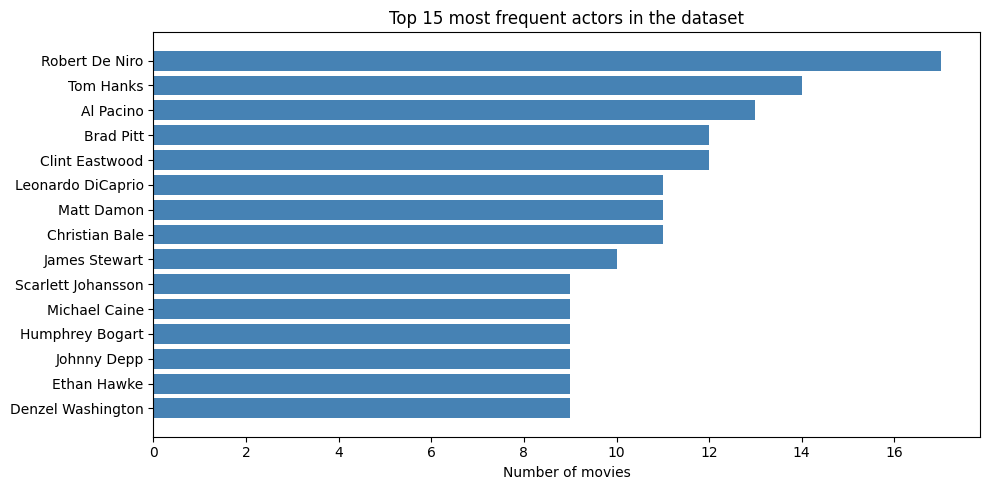

In [28]:
import matplotlib.pyplot as plt

top_actors = (
    frequent_itemsets[frequent_itemsets['itemset_size'] == 1]
    .sort_values('count', ascending=False)
    .head(15)
)
top_actors['actor'] = top_actors['itemsets'].apply(lambda x: list(x)[0])

plt.figure(figsize=(10, 5))
plt.barh(top_actors['actor'], top_actors['count'], color='steelblue')
plt.xlabel('Number of movies')
plt.title('Top 15 most frequent actors in the dataset')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_actors.png', dpi=150)
plt.show()

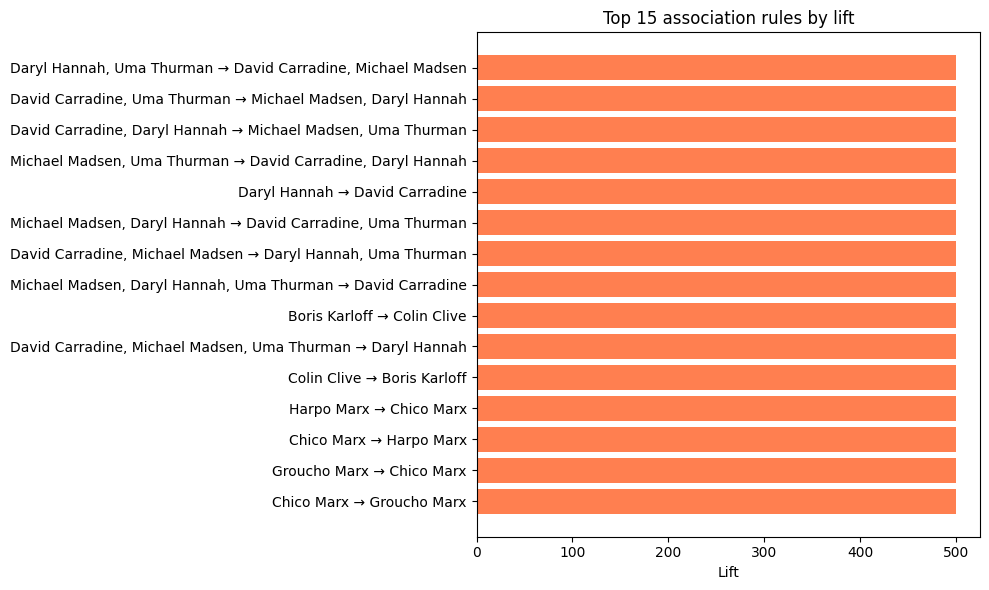

In [29]:
top_rules = rules.head(15).copy()
top_rules['rule'] = (
    top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) +
    ' → ' +
    top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
)

plt.figure(figsize=(10, 6))
plt.barh(top_rules['rule'], top_rules['lift'], color='coral')
plt.xlabel('Lift')
plt.title('Top 15 association rules by lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_rules.png', dpi=150)
plt.show()

Scalability experiment

n=100: 0.008s
n=200: 0.010s
n=300: 0.019s
n=500: 0.070s
n=750: 0.242s
n=1000: 0.737s


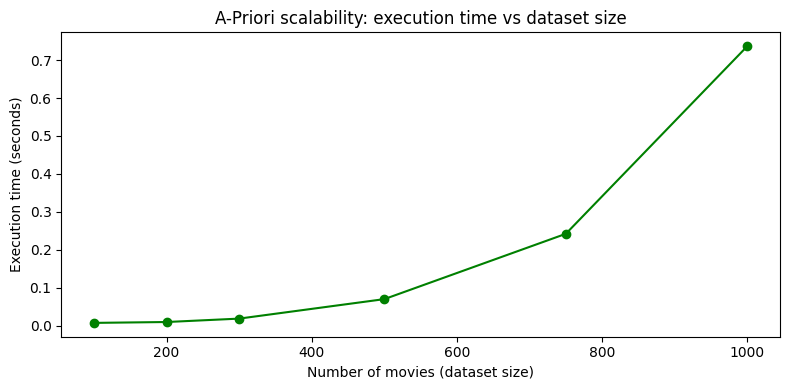

In [30]:
import time

sizes = [100, 200, 300, 500, 750, 1000]
times = []

for size in sizes:
    sample = basket_df.sample(n=size, random_state=42)
    min_sup = 2 / size
    start = time.time()
    apriori(sample, min_support=min_sup, use_colnames=True, max_len=4)
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"n={size}: {elapsed:.3f}s")

plt.figure(figsize=(8, 4))
plt.plot(sizes, times, marker='o', color='green')
plt.xlabel('Number of movies (dataset size)')
plt.ylabel('Execution time (seconds)')
plt.title('A-Priori scalability: execution time vs dataset size')
plt.tight_layout()
plt.savefig('scalability.png', dpi=150)
plt.show()